In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [24]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

# Load All Datasets

In [25]:
df_ddos = pd.read_csv(
    "/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
)
df_portscan = pd.read_csv(
    "/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"
)
df_web = pd.read_csv(
    "/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv"
)
df_bot = pd.read_csv(
    "/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv"
)

# Clean All Datasets

In [26]:
datasets = [
    df_ddos,
    df_portscan,
    df_web,
    df_bot
]

for df in datasets:

    df.columns = df.columns.str.strip()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    df.dropna(inplace=True)

# Combine Datasets

In [27]:
combined_df = pd.concat(
    [
        df_ddos,
        df_portscan,
        df_web,
        df_bot
    ],
    ignore_index=True
)

# Verify Attack Classes

In [28]:
combined_df["Label"].value_counts()

Label
BENIGN              853616
DoS Hulk            230124
PortScan            158804
DDoS                128025
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Bot                   1956
Heartbleed              11
Name: count, dtype: int64

In [29]:
valid_classes = [
    "BENIGN",
    "DoS Hulk",
    "DDoS",
    "PortScan",
    "Bot"
]

combined_df = combined_df[
    combined_df["Label"].isin(valid_classes)
]

In [30]:
combined_df = combined_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Encode Labels

In [31]:
encoder = LabelEncoder()

combined_df["Label"] = encoder.fit_transform(
    combined_df["Label"]
)

In [33]:
selected_features = [

    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",

    "Fwd Packet Length Max",
    "Fwd Packet Length Min",
    "Fwd Packet Length Mean",

    "Bwd Packet Length Std",

    "Flow Bytes/s",
    "Flow Packets/s",

    "Average Packet Size",

    "Idle Mean",
    "Active Mean",
    "Active Std",

    "SYN Flag Count",
    "PSH Flag Count",
    "ACK Flag Count",
    "RST Flag Count",
    "FIN Flag Count",

    "Bwd Header Length",
    "act_data_pkt_fwd"
]

# Split Features & Labels

In [34]:
X = combined_df[selected_features]

y = combined_df["Label"]

In [37]:
valid_classes = [
    "BENIGN",
    "DoS Hulk",
    "DDoS",
    "PortScan",
    "Bot"
]

combined_df = combined_df[
    combined_df["Label"].isin(valid_classes)
]

# Train-Test Split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Train Final Enterprise Model

In [40]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    tree_method="hist"
)

In [41]:
model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluate

In [42]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9700916194604834
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    170723
           1       0.06      0.99      0.12       391
           2       1.00      1.00      1.00     25605
           3       0.95      1.00      0.97     46025
           4       1.00      1.00      1.00     31761

    accuracy                           0.97    274505
   macro avg       0.80      0.99      0.81    274505
weighted avg       0.99      0.97      0.98    274505



# Save Final Model

In [43]:
joblib.dump(model, "final_multi_attack_model.pkl")

joblib.dump(encoder, "final_multi_attack_encoder.pkl")

['final_multi_attack_encoder.pkl']

# Feature Importance

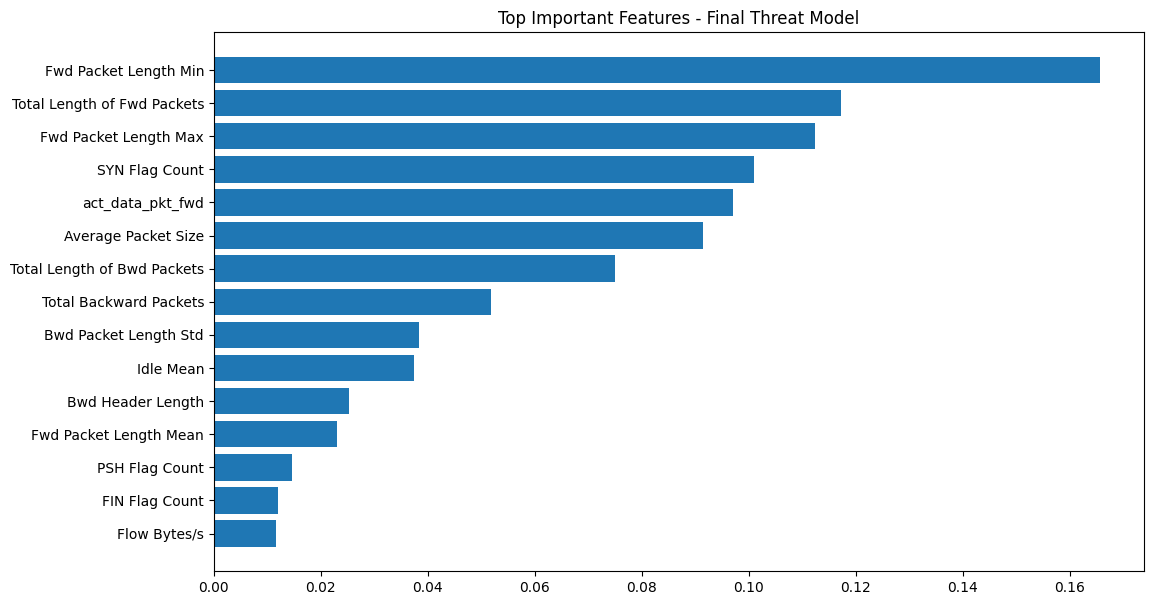

In [44]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance_df.head(15)

plt.figure(figsize=(12,7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Important Features - Final Threat Model")

plt.show()